<a href="https://www.kaggle.com/code/hrishikeshsoudagar/uber-pickups-demand-forecasting?scriptVersionId=312849358" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Reading Dataset

In [2]:
apr = pd.read_csv('/kaggle/input/datasets/organizations/fivethirtyeight/uber-pickups-in-new-york-city/uber-raw-data-apr14.csv')
may = pd.read_csv('/kaggle/input/datasets/organizations/fivethirtyeight/uber-pickups-in-new-york-city/uber-raw-data-may14.csv')
jun = pd.read_csv('/kaggle/input/datasets/organizations/fivethirtyeight/uber-pickups-in-new-york-city/uber-raw-data-jun14.csv')
jul = pd.read_csv('/kaggle/input/datasets/organizations/fivethirtyeight/uber-pickups-in-new-york-city/uber-raw-data-jul14.csv')
aug = pd.read_csv('/kaggle/input/datasets/organizations/fivethirtyeight/uber-pickups-in-new-york-city/uber-raw-data-aug14.csv')
sep = pd.read_csv('/kaggle/input/datasets/organizations/fivethirtyeight/uber-pickups-in-new-york-city/uber-raw-data-sep14.csv')

df = pd.concat([apr,may,jun,jul,aug,sep])

df

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
...,...,...,...,...
1028131,9/30/2014 22:57:00,40.7668,-73.9845,B02764
1028132,9/30/2014 22:57:00,40.6911,-74.1773,B02764
1028133,9/30/2014 22:58:00,40.8519,-73.9319,B02764
1028134,9/30/2014 22:58:00,40.7081,-74.0066,B02764


Getting Info 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4534327 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 173.0+ MB


Checking For Missing Values

In [4]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

Converting A Column To Date Time

In [5]:
df['Date/Time']=pd.to_datetime(df['Date/Time'])

In [6]:
df['Hour']=df['Date/Time'].dt.hour
df['Day']=df['Date/Time'].dt.day
df['Month']=df['Date/Time'].dt.month
df['Weekday']=df['Date/Time'].dt.weekday

Histogram Pickup Hourly Distribution

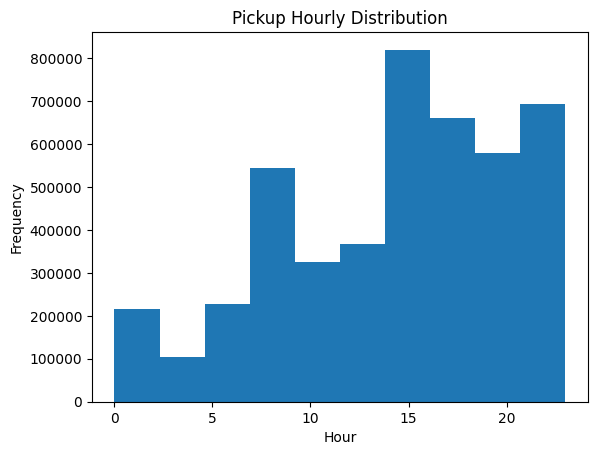

In [7]:
plt.figure()
plt.hist(df['Hour'])
plt.title('Pickup Hourly Distribution')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.show()

Bar Chart By Hourly Pickup

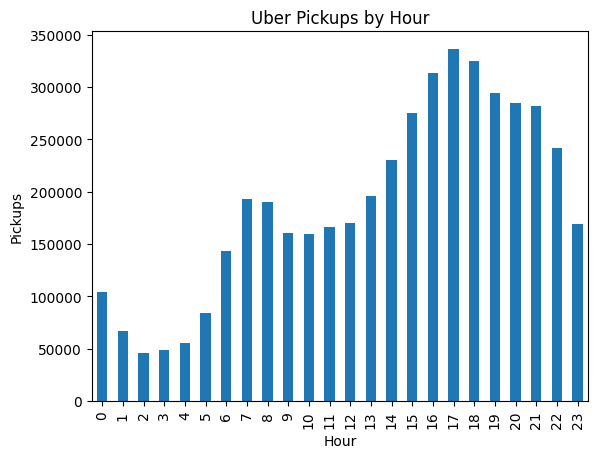

In [8]:
hourly=df['Hour'].value_counts().sort_index()
plt.figure()
hourly.plot(kind='bar')
plt.title("Uber Pickups by Hour")
plt.xlabel("Hour")
plt.ylabel("Pickups")
plt.show()

Line Chart Pickup By Day

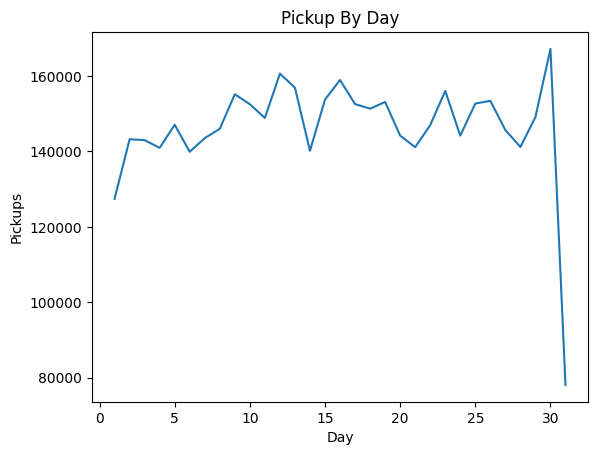

In [9]:
daily=df['Day'].value_counts().sort_index()
plt.figure()
daily.plot(kind='line')
plt.title('Pickup By Day')
plt.xlabel("Day")
plt.ylabel('Pickups')
plt.show()

Pickup By Weekday Countplot

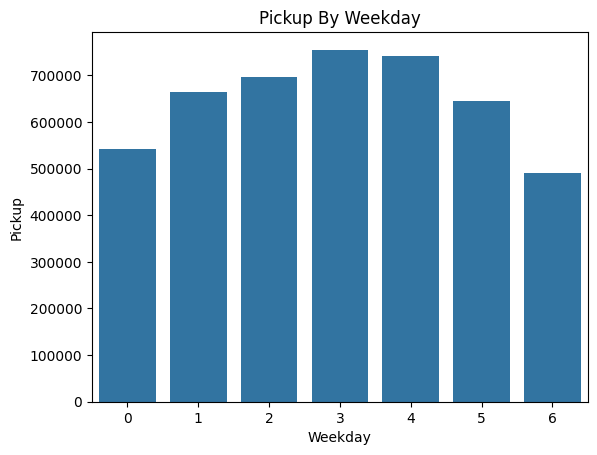

In [10]:
plt.figure()
sns.countplot(x=df["Weekday"])
plt.title('Pickup By Weekday')
plt.xlabel('Weekday')
plt.ylabel('Pickup')
plt.show()

Pickup By Month Countplot

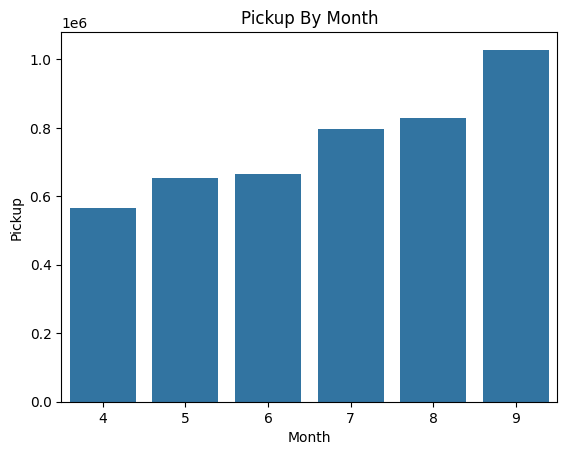

In [11]:
plt.figure()
sns.countplot(x=df["Month"])
plt.title('Pickup By Month')
plt.xlabel('Month')
plt.ylabel('Pickup')
plt.show()

Uber Pickup Demand Heatmap 

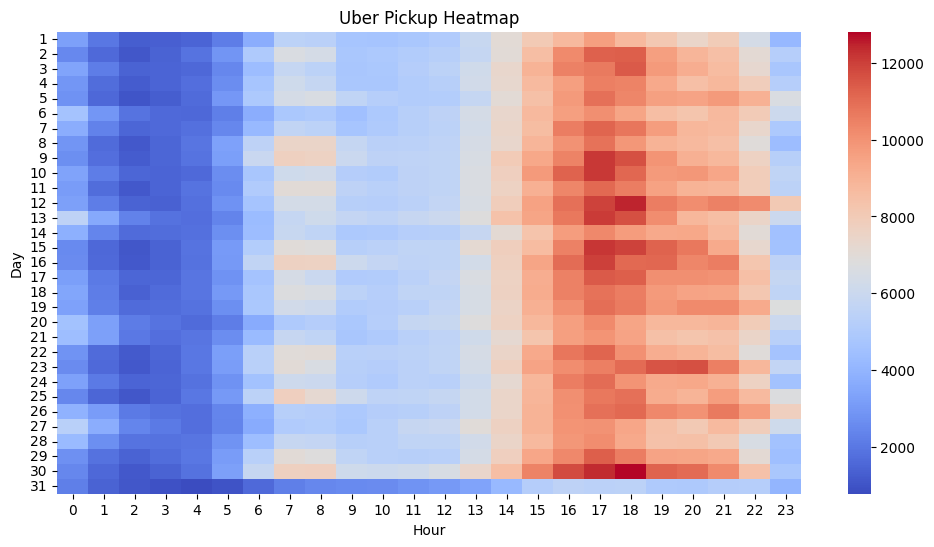

In [12]:
heatmap_data = pd.crosstab(df['Day'],df['Hour'])
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap='coolwarm')
plt.title("Uber Pickup Heatmap")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

Scatter Plot For Pickup Location

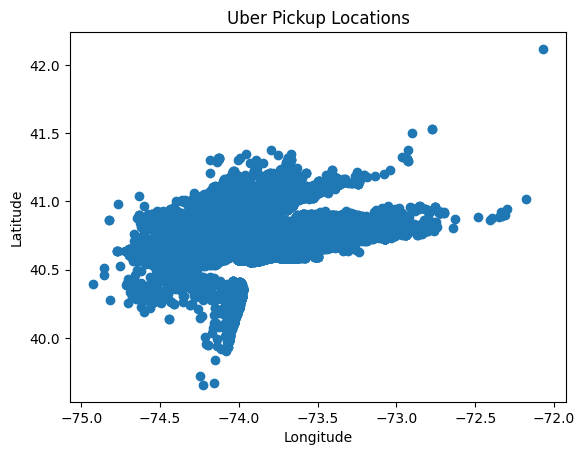

In [13]:
plt.figure()
plt.scatter(df['Lon'], df['Lat'])
plt.title("Uber Pickup Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Box Plot For Hourly Distribution

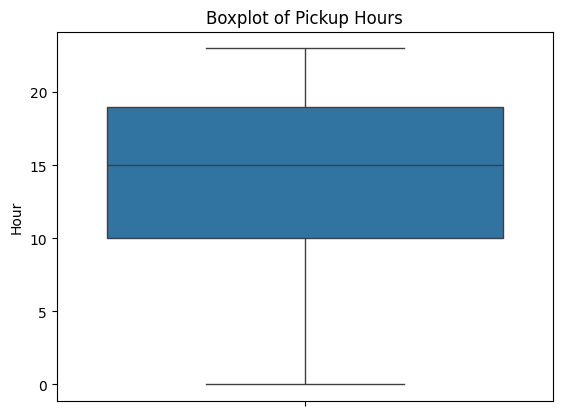

In [14]:
plt.figure()
sns.boxplot(y=df['Hour'])
plt.title("Boxplot of Pickup Hours")
plt.show()

Creating Demand Dataset

In [15]:
demand = df[['Month','Day','Hour','Weekday']].value_counts().reset_index(name='Pickup')

demand.head()

,Month,Day,Hour,Weekday,Pickup
0,9,13,18,5,3437
1,9,13,19,5,3332
2,7,15,18,1,3302
3,7,15,19,1,3225
4,9,18,18,3,3225


Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x=demand[['Month','Day','Hour','Weekday']]
y=demand['Pickup']

In [18]:
x

,Month,Day,Hour,Weekday
0,9,13,18,5
1,9,13,19,5
2,7,15,18,1
3,7,15,19,1
4,9,18,18,3
...,...,...,...,...
4386,4,7,2,0
4387,4,1,2,1
4388,5,5,2,0
4389,4,14,1,0


In [19]:
y

0       3437
1       3332
2       3302
3       3225
4       3225
        ... 
4386      57
4387      53
4388      52
4389      48
4390      45
Name: Pickup, Length: 4391, dtype: int64

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Training Machine Learning Model

Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
model=RandomForestRegressor(n_estimators=200,max_depth=15,random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

In [23]:
pred=model.predict(x_test)

pred

array([ 192.29383333, 1218.47      ,  704.4       ,  722.875     ,
        881.565     , 1750.17708333, 1704.4035979 , 1090.92779538,
       1925.94514693, 1078.911     , 1011.37224064, 1052.23      ,
       1296.35      ,  669.185     ,  243.6275    , 1023.3       ,
        824.295     ,  659.74464286, 1479.42125   ,  602.04      ,
       1114.25      ,  147.22875   ,  939.675     , 1212.38339039,
       1635.21534957,  754.66      , 2057.87229606, 1120.869     ,
       1433.52266667, 1379.55      ,  253.68984993,  164.27916667,
       1058.805     ,  485.745     ,  289.885     , 1286.96933333,
       1366.87353968, 1082.34030707, 1772.39375   ,  256.08708333,
       1075.17520479, 1219.25406582, 1311.29199186, 1374.43125389,
       1063.489375  , 1091.34145256,  848.345     , 1673.82319949,
        774.15      ,  628.45676609,  662.15746429,  198.28666667,
        428.7       ,  213.78710714, 1359.31059524, 1049.60375   ,
        565.3925    , 1471.1791194 , 1384.09221265, 1186.31816

In [24]:
from sklearn.metrics import mean_absolute_error

In [25]:
mae=mean_absolute_error(y_test,pred)

In [26]:
mae

93.75244447926053

XGB Regressor

In [27]:
from xgboost import XGBRegressor

In [28]:
model1= XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42)

model1.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [29]:
pred1 = model1.predict(x_test)

In [30]:
mae1 = mean_absolute_error(y_test,pred1)
mae1

83.08958435058594

GradientBoostingRegressor

In [31]:
from sklearn.ensemble import GradientBoostingRegressor

In [32]:
model2 = GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=5)

model2.fit(x_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300)

In [33]:
pred2 = model2.predict(x_test)

In [34]:
mae2 = mean_absolute_error(y_test,pred2)
mae2

92.01350779210438

In [35]:
print("Random Forest MAE:",mae)
print("XGB Regressor MAE:",mae1)
print("Gradient Boosting MAE:",mae2)

Random Forest MAE: 93.75244447926053
XGB Regressor MAE: 83.08958435058594
Gradient Boosting MAE: 92.01350779210438


Model Comparison

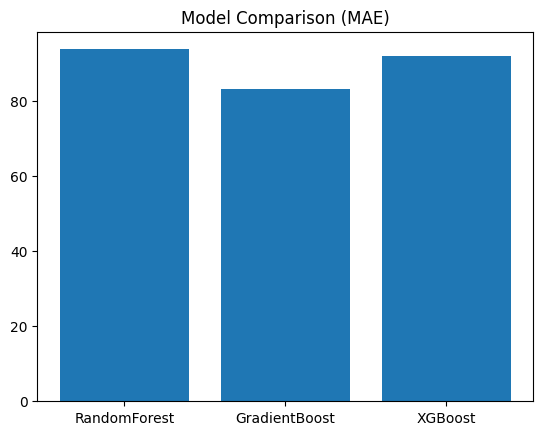

In [36]:
models = ['RandomForest','GradientBoost','XGBoost']
mae_scores = [mae,mae1,mae2]
plt.figure()
plt.bar(models,mae_scores)
plt.title("Model Comparison (MAE)")
plt.show()

Feature Importance

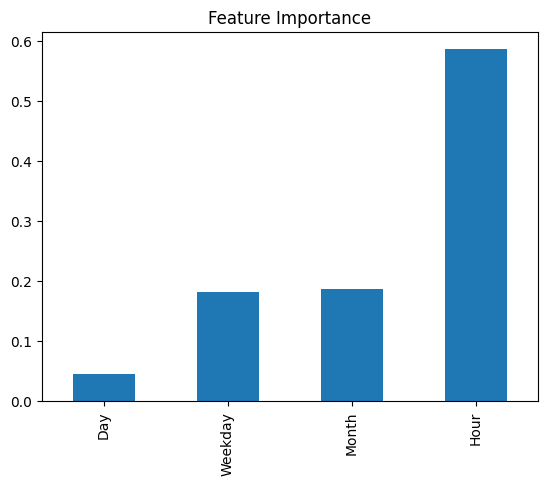

In [37]:
importance = pd.Series(model1.feature_importances_,index=x.columns) #Using XGB Regressor as a model here 
plt.figure()
importance.sort_values().plot(kind='bar')
plt.title("Feature Importance")
plt.show()

Actual Vs Predicted

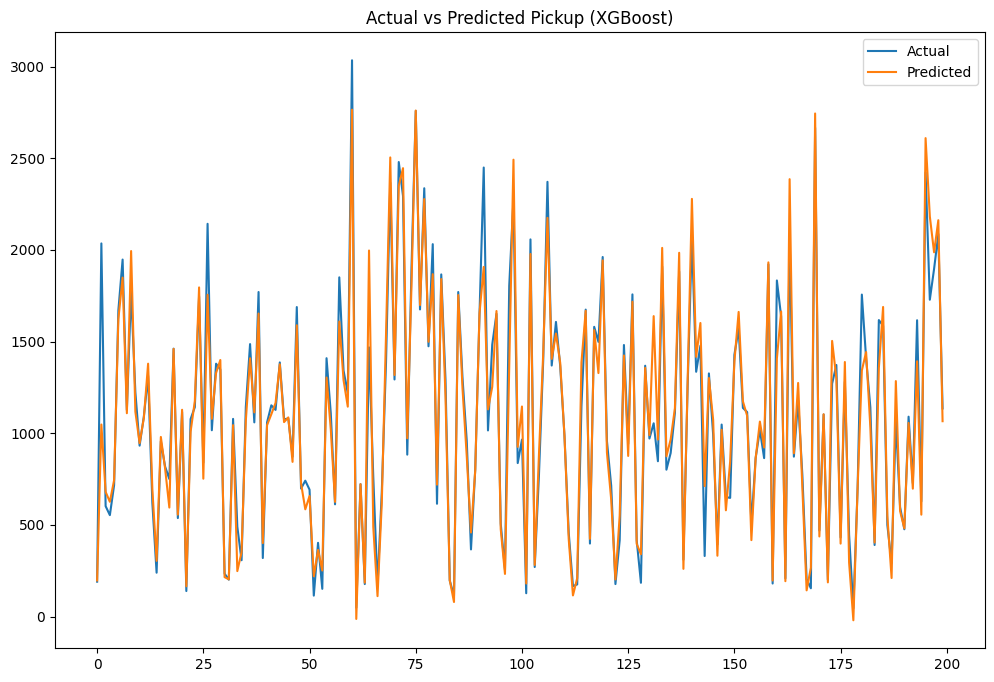

In [38]:
plt.figure(figsize=(12,8))
plt.plot(y_test.values[:200], label='Actual') #Considering only 200 samples 
plt.plot(pred1[:200], label='Predicted')  
plt.legend()
plt.title("Actual vs Predicted Pickup (XGBoost)")
plt.show()

Conclusion

#In this project,the uber pickup data was analyzed to identify the demand based on time features such as hour,day,month and weekday.EDA(Exploratory data analysis ) helped uncover peak demand hours and usage trends.

#Three machine learning models were trained to predict the pickup demand-Random Forest,Gradient Boosting and XGBoost.Among them XGBoost achieved the best performance with the lowest Mean Absolute Error.

#The results show that machine learning models can effectively forecast ride demand and help ride-sharing companies improve ooperational efficiency and resource planning.